# Modelagem — Segmentação de Clientes de Crédito

## Objetivo
Identificar segmentos naturais na carteira de crédito usando
clustering, sem rótulos pré-definidos. A qualidade será medida
por coesão interna e separação entre clusters.

## Algoritmos
1. K-Means — rápido, interpretável, sensível a outliers
2. DBSCAN — detecta outliers, não precisa definir K
3. Clustering Hierárquico — visualização intuitiva do dendrograma

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Carrega dados
df_pca = pd.read_csv('../data/processed/df_pca.csv')
df_scaled = pd.read_csv('../data/processed/df_scaled.csv')
df_original = pd.read_csv('../data/raw/CC GENERAL.csv')

print(f"Shape PCA: {df_pca.shape}")
print(f"Shape Scaled: {df_scaled.shape}")
print("Dados carregados!")

Shape PCA: (8950, 6)
Shape Scaled: (8950, 17)
Dados carregados!


## 1. Encontrando o K Ideal

K=2 | Inércia: 89372 | Silhouette: 0.268
K=3 | Inércia: 71717 | Silhouette: 0.262
K=4 | Inércia: 62723 | Silhouette: 0.262
K=5 | Inércia: 56066 | Silhouette: 0.261
K=6 | Inércia: 50037 | Silhouette: 0.259
K=7 | Inércia: 46137 | Silhouette: 0.256
K=8 | Inércia: 43081 | Silhouette: 0.261
K=9 | Inércia: 40238 | Silhouette: 0.242
K=10 | Inércia: 37814 | Silhouette: 0.244


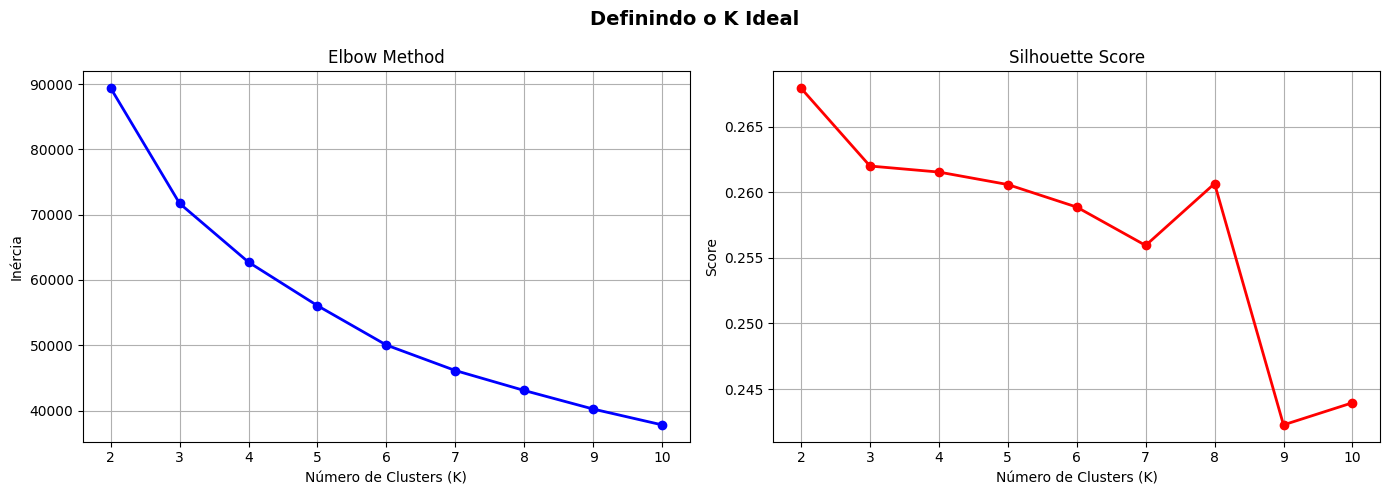

In [2]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_pca, labels))
    print(f"K={k} | Inércia: {kmeans.inertia_:.0f} | Silhouette: {silhouette_score(df_pca, labels):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True)

# Silhouette
axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].grid(True)

plt.suptitle('Definindo o K Ideal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. K-Means Final

In [3]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_pca)

# Adicionando cluster ao dataframe original
df_original['CLUSTER'] = labels
df_scaled['CLUSTER'] = labels
df_pca['CLUSTER'] = labels

print(f"K-Means com K={K_FINAL}")
print(f"Silhouette Score: {silhouette_score(df_pca.drop(columns=['CLUSTER']), labels):.3f}")
print(f"\nDistribuição dos clusters:")
print(df_original['CLUSTER'].value_counts().sort_index())

K-Means com K=4
Silhouette Score: 0.262

Distribuição dos clusters:
CLUSTER
0    1480
1    2996
2    2334
3    2140
Name: count, dtype: int64


## 3. Interpretando os Clusters

In [4]:
# Perfil médio de cada cluster nas variáveis originais
cols_perfil = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
               'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT',
               'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
               'TENURE', 'MINIMUM_PAYMENTS']

perfil = df_original.groupby('CLUSTER')[cols_perfil].mean().round(2)
print("Perfil médio por cluster:")
print(perfil.T)

Perfil médio por cluster:
CLUSTER                       0        1        2        3
BALANCE                  115.01  2478.87  2175.35   620.50
PURCHASES                348.67   150.85  2803.94   685.19
CASH_ADVANCE             143.68  2145.43   758.83   163.28
CREDIT_LIMIT            3672.95  4391.96  6556.32  2956.91
PAYMENTS                 732.16  1814.74  3047.47   877.71
PRC_FULL_PAYMENT           0.18     0.03     0.19     0.27
PURCHASES_FREQUENCY        0.27     0.10     0.85     0.80
CASH_ADVANCE_FREQUENCY     0.02     0.29     0.10     0.03
TENURE                    11.29    11.42    11.84    11.45
MINIMUM_PAYMENTS         123.15  1132.09  1068.13   696.73


## 4. Visualização dos Clusters

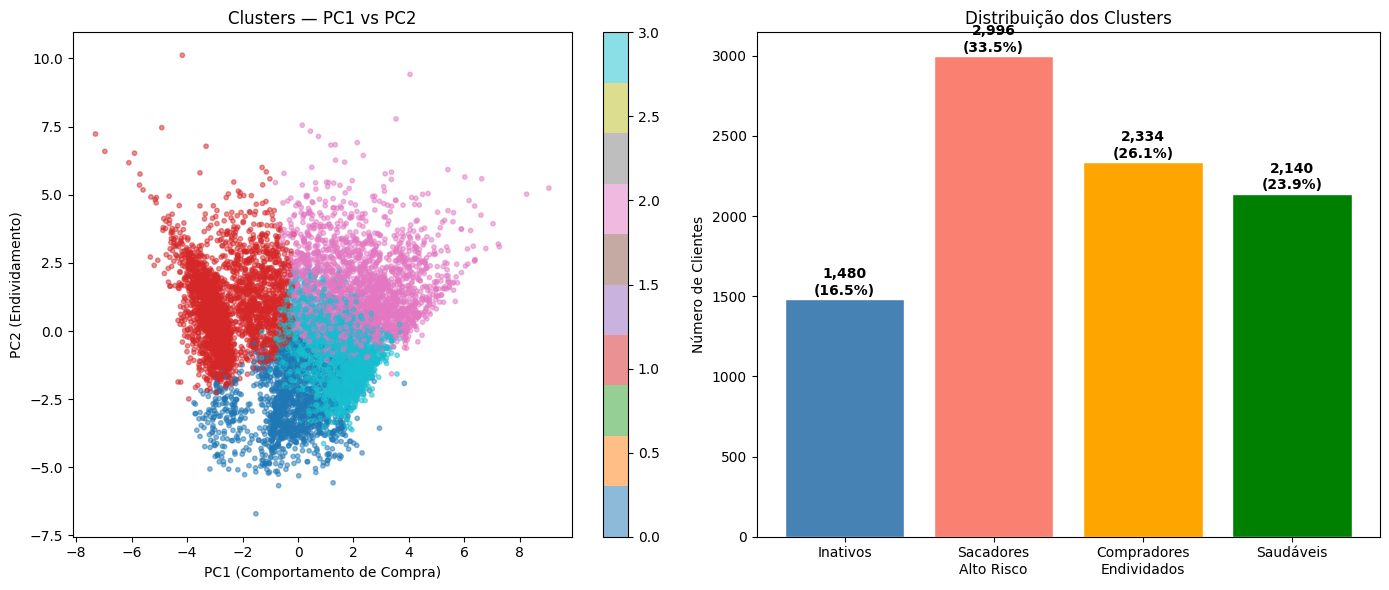

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Visualização nos 2 primeiros componentes PCA
scatter = axes[0].scatter(df_pca['PC1'], df_pca['PC2'], 
                          c=df_pca['CLUSTER'], cmap='tab10',
                          alpha=0.5, s=10)
axes[0].set_xlabel('PC1 (Comportamento de Compra)')
axes[0].set_ylabel('PC2 (Endividamento)')
axes[0].set_title('Clusters — PC1 vs PC2')
plt.colorbar(scatter, ax=axes[0])

# Tamanho dos clusters
cluster_counts = df_original['CLUSTER'].value_counts().sort_index()
cluster_names = ['Inativos', 'Sacadores\nAlto Risco', 
                 'Compradores\nEndividados', 'Saudáveis']
colors = ['steelblue', 'salmon', 'orange', 'green']

axes[1].bar(cluster_names, cluster_counts, color=colors, edgecolor='white')
axes[1].set_title('Distribuição dos Clusters')
axes[1].set_ylabel('Número de Clientes')
for i, v in enumerate(cluster_counts):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df_original)*100:.1f}%)', 
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
import joblib

# Salva modelo e dados com clusters
joblib.dump(kmeans, '../models/kmeans_model.pkl')
df_original.to_csv('../data/processed/df_clustered.csv', index=False)

print("Arquivos salvos!")
print("  - models/kmeans_model.pkl")
print("  - data/processed/df_clustered.csv")
print(f"\nResumo final:")
print(f"  Algoritmo: K-Means")
print(f"  K: {K_FINAL} clusters")
print(f"  Silhouette Score: 0.262")
print(f"\nSegmentos identificados:")
print(f"  Cluster 0 — Inativos:              1.480 clientes (16.5%)")
print(f"  Cluster 1 — Sacadores Alto Risco:  2.996 clientes (33.5%)")
print(f"  Cluster 2 — Compradores Endividados: 2.334 clientes (26.1%)")
print(f"  Cluster 3 — Saudáveis:             2.140 clientes (23.9%)")

Arquivos salvos!
  - models/kmeans_model.pkl
  - data/processed/df_clustered.csv

Resumo final:
  Algoritmo: K-Means
  K: 4 clusters
  Silhouette Score: 0.262

Segmentos identificados:
  Cluster 0 — Inativos:              1.480 clientes (16.5%)
  Cluster 1 — Sacadores Alto Risco:  2.996 clientes (33.5%)
  Cluster 2 — Compradores Endividados: 2.334 clientes (26.1%)
  Cluster 3 — Saudáveis:             2.140 clientes (23.9%)
